Original image size: (224, 224)
Resized image size: (224, 224)


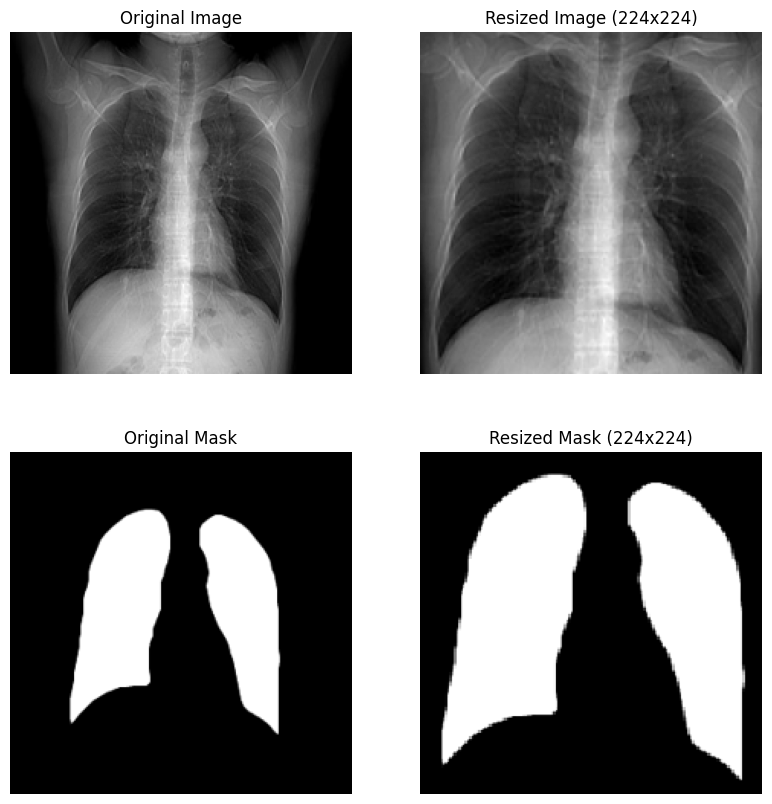

In [1]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def label_aware_zoom(image, mask, padding=10, target_size=(224, 224)):
    # Find the bounding box of the important part (value 1 or 255) in the mask
    coords = np.column_stack(np.where((mask == 1) | (mask == 255)))

    # If there are no '1' or '255' pixels in the mask, return the original image and mask
    if coords.size == 0:
        print("Warning: No important regions found in the mask.")
        return image, mask

    top_left = coords.min(axis=0)
    bottom_right = coords.max(axis=0)

    # Optionally, expand the bounding box by a padding value (be careful with image boundaries)
    top_left = np.maximum(top_left - padding, 0)
    bottom_right = np.minimum(bottom_right + padding, mask.shape)

    # Crop the mask and image using the bounding box
    cropped_mask = mask[top_left[0]:bottom_right[0], top_left[1]:bottom_right[1]]
    cropped_image = image[top_left[0]:bottom_right[0], top_left[1]:bottom_right[1]]

    # Resize the cropped image and mask to the target size (224x224)
    resized_image = cv2.resize(cropped_image, target_size, interpolation=cv2.INTER_AREA)
    resized_mask = cv2.resize(cropped_mask, target_size, interpolation=cv2.INTER_NEAREST)

    return resized_image, resized_mask

# Example usage:
# Load your image and mask (for example, using OpenCV)
image = cv2.imread('COVID (340).png', cv2.IMREAD_GRAYSCALE)
mask = cv2.imread('COVID (340)_mask.png', cv2.IMREAD_GRAYSCALE)

# Perform label-aware zoom and resizing
resized_image, resized_mask = label_aware_zoom(image, mask)

# Print sizes of the images
print(f"Original image size: {image.shape}")
print(f"Resized image size: {resized_image.shape}")

# Display original and resized images with their masks
def display_images(image, mask, resized_image, resized_mask):
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(resized_image, cmap='gray')
    plt.title("Resized Image (224x224)")
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(mask, cmap='gray')
    plt.title("Original Mask")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(resized_mask, cmap='gray')
    plt.title("Resized Mask (224x224)")
    plt.axis('off')

    plt.show()

# Display the results
display_images(image, mask, resized_image, resized_mask)


Original image size: (224, 224)
Cropped image size: (150, 150)
Resized image size: (224, 224)


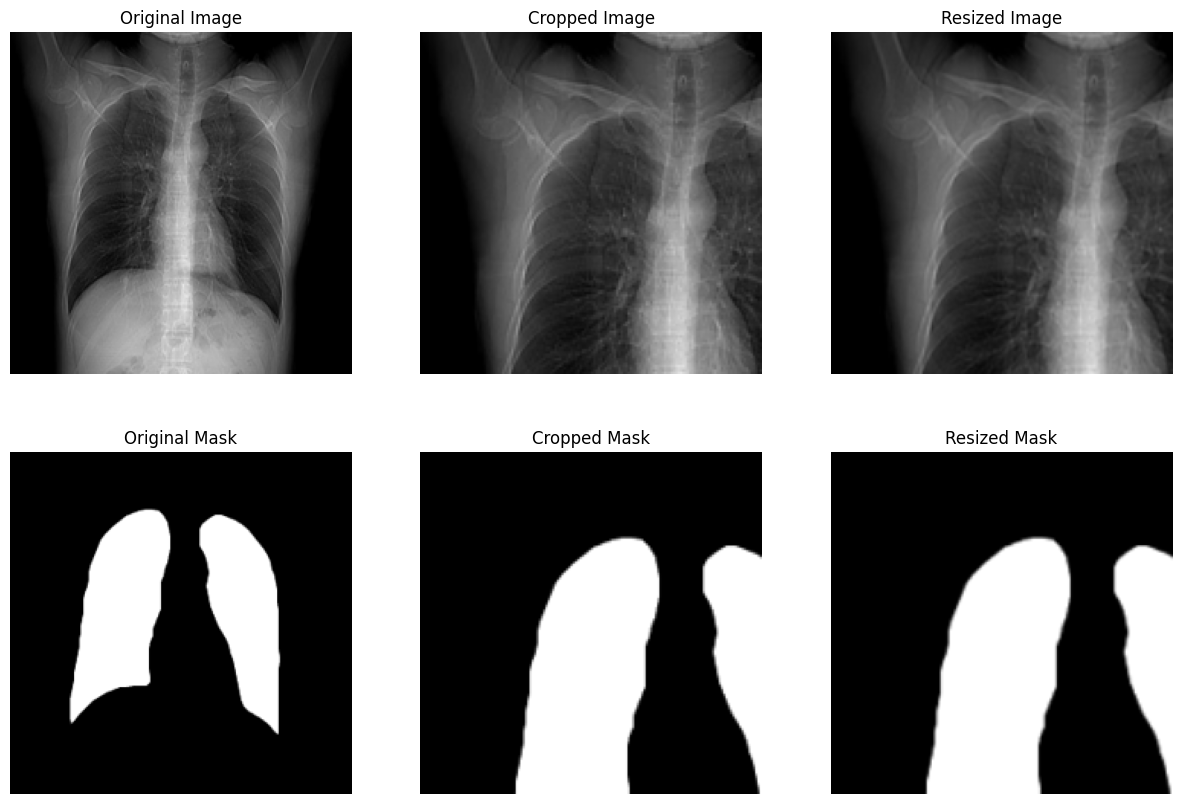

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded image and its mask
image_path = './COVID (340).png'
mask_path = './COVID (340)_mask.png'

image = Image.open(image_path).convert('RGB')
mask = Image.open(mask_path).convert('L')  # Convert mask to grayscale

def label_aware_cropping(image, mask, crop_size=(150, 150)):
    """
    Crop the image in a way that always includes labeled regions.
    Args:
        image (PIL Image): The input image to crop.
        mask (PIL Image): The mask defining regions of interest.
        crop_size (tuple): The size of the crop (width, height).
    Returns:
        PIL Image, PIL Image: Cropped image and mask.
    """
    width, height = image.size
    mask_array = np.array(mask)

    # Find bounding box of non-zero regions in the mask
    non_zero_indices = np.argwhere(mask_array > 0)
    if non_zero_indices.size == 0:
        # If no labeled region, fallback to random cropping
        return random_cropping(image, crop_size), random_cropping(mask, crop_size)

    # Get bounding box of labeled region
    y_min, x_min = non_zero_indices.min(axis=0)
    y_max, x_max = non_zero_indices.max(axis=0)

    # Calculate cropping area to include the labeled regions
    crop_x_min = max(0, min(x_min - crop_size[0] // 2, width - crop_size[0]))
    crop_y_min = max(0, min(y_min - crop_size[1] // 2, height - crop_size[1]))
    crop_x_max = crop_x_min + crop_size[0]
    crop_y_max = crop_y_min + crop_size[1]

    cropped_image = image.crop((crop_x_min, crop_y_min, crop_x_max, crop_y_max))
    cropped_mask = mask.crop((crop_x_min, crop_y_min, crop_x_max, crop_y_max))

    return cropped_image, cropped_mask

def resize_image(image, target_size=(224, 224)):
    """
    Resize the image to the target size.
    Args:
        image (PIL Image): The input image to resize.
        target_size (tuple): The target size (width, height).
    Returns:
        PIL Image: Resized image.
    """
    return image.resize(target_size, Image.BILINEAR)

# Step 1: Label-aware cropping (zoom-in effect)
cropped_image, cropped_mask = label_aware_cropping(image, mask, crop_size=(150, 150))

# Step 2: Resize cropped image back to 224x224
resized_image = resize_image(cropped_image, target_size=(224, 224))
resized_mask = resize_image(cropped_mask, target_size=(224, 224))

# Print sizes of the images
print(f"Original image size: {image.size}")
print(f"Cropped image size: {cropped_image.size}")
print(f"Resized image size: {resized_image.size}")

# Display original, cropped, and resized images with their masks
def display_images(original, cropped, resized, mask, cropped_mask, resized_mask):
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(cropped)
    plt.title("Cropped Image")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(resized)
    plt.title("Resized Image")
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(mask, cmap='gray')
    plt.title("Original Mask")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(cropped_mask, cmap='gray')
    plt.title("Cropped Mask")
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(resized_mask, cmap='gray')
    plt.title("Resized Mask")
    plt.axis('off')

    plt.show()

# Display the results
display_images(image, cropped_image, resized_image, mask, cropped_mask, resized_mask)


Original image size: (224, 224)
Zoomed-out image size: (224, 224)


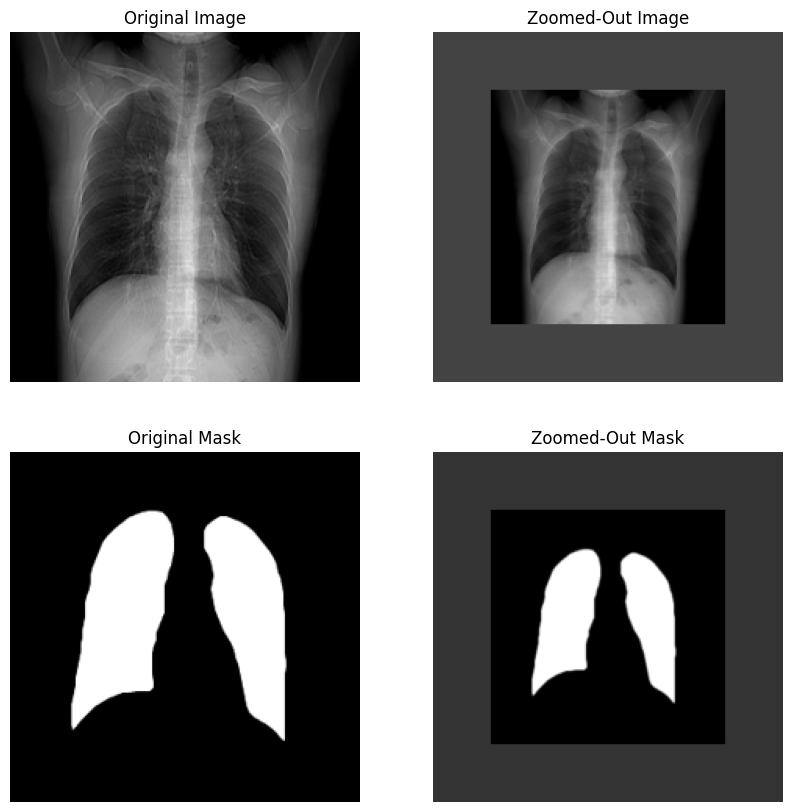

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded image and its mask
image_path = './COVID (340).png'
mask_path = './COVID (340)_mask.png'

image = Image.open(image_path).convert('RGB')
mask = Image.open(mask_path).convert('L')  # Convert mask to grayscale

def zoom_out(image, target_size=(224, 224), zoomed_size=(150, 150)):
    """
    Resize the image to a smaller size and place it in the center of a new image with margins filled with the average color.
    Args:
        image (PIL Image): The input image to zoom out.
        target_size (tuple): The size of the output image (width, height).
        zoomed_size (tuple): The size of the zoomed-out image (width, height).
    Returns:
        PIL Image: Image with zoom-out effect.
    """
    # Resize the image to the zoomed-out size
    zoomed_image = image.resize(zoomed_size, Image.BILINEAR)

    # Calculate the average color of the original image
    average_color = np.array(image).mean(axis=(0, 1)).astype(np.uint8)
    avg_color_img = Image.new('RGB', target_size, tuple(average_color))

    # Calculate the position to paste the zoomed image on the average color background
    paste_x = (target_size[0] - zoomed_size[0]) // 2
    paste_y = (target_size[1] - zoomed_size[1]) // 2

    # Paste the zoomed image onto the center of the average color background
    avg_color_img.paste(zoomed_image, (paste_x, paste_y))

    return avg_color_img

# Step 1: Zoom out effect
zoomed_out_image = zoom_out(image, target_size=(224, 224), zoomed_size=(150, 150))
zoomed_out_mask = zoom_out(mask.convert('RGB'), target_size=(224, 224), zoomed_size=(150, 150)).convert('L')

# Print sizes of the images
print(f"Original image size: {image.size}")
print(f"Zoomed-out image size: {zoomed_out_image.size}")

# Display original, zoomed-out images with their masks
def display_images(original, zoomed_out, mask, zoomed_out_mask):
    plt.figure(figsize=(10, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(zoomed_out)
    plt.title("Zoomed-Out Image")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(mask, cmap='gray')
    plt.title("Original Mask")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(zoomed_out_mask, cmap='gray')
    plt.title("Zoomed-Out Mask")
    plt.axis('off')

    plt.show()

# Display the results
display_images(image, zoomed_out_image, mask, zoomed_out_mask)
